# 📋 Resumen Ejecutivo — TASS 2018 Análisis de Sentimientos

**Laboratorio 1 — NLP**  |  **Corpus:** TASS 2018 ES  |  **Tarea:** Clasificación de polaridad (4 clases: P · N · NEU · NONE)

---

## Estructura del Notebook

| Sección | Contenido |
|---------|-----------|
| §1–§16  | **Baseline del Profesor** — BoW + Softmax original, sin modificaciones |
| §17–§19 | **Setup + EDA + Evaluación Honesta** del baseline (sin data leakage) |
| §24     | **Pipeline V3** — `TextProcessing` (spaCy) + `SentimentFeaturesTransformer` (**26 features**, **7 sets del léxico** de `Actividades/logic/`) |
| §25     | **Comparativa 6 × 4** — 6 clasificadores × 4 estrategias de balanceo · StratifiedKFold k=5 · `imblearn.Pipeline` |
| §26     | **Evaluación en Test** — top-3 del ranking CV evaluados en el test set honesto |
| §27     | **Análisis de Errores** — matriz de confusión · tasa por clase · pares de confusión · top-15 errores de alta confianza |
| §28     | **Demo** — función `predict_sentiment()` · sin serialización de artefactos |
| §34     | **Tabla Final** — heatmap 6×4 + comparativa baseline vs mejor modelo |

---

## Decisiones de Diseño — Pipeline V3

| Componente | Decisión | Justificación |
|------------|----------|---------------|
| Preprocesador | `TextProcessing` de `logic/text_processing.py` (spaCy `es_core_news_sm` + corrección ortográfica + emoji polarity + negación ext. 4 tokens) | Lematización real; emoji_pos/neg; español informal |
| Vectorización | TF-IDF word(1,2) + char\_wb(3,4) — max 15K + 20K features | Captura morfología española |
| Léxico | **7 sets** de `logic/lexicon_es.py` — 309 pos · 322 neg · negadores · intensificadores · atenuadores · 33+36 bigramas | Cobertura coloquial ES/LATAM |
| Features manuales | **26 features** — subjectivity · is\_question · emoji\_pos/neg · all\_caps · suspensivo · code-switch · posición de negación | Todas numéricas → compatibles con ComplementNB |
| Balanceo | 4 estrategias (over\_puro · under\_puro · smote · smotetomek) **dentro del fold** vía `imblearn.Pipeline` | Cero data leakage |
| Clasificadores | 6 modelos: Softmax LR · SVM Lineal · ComplementNB · RandomForest · HistGradBoost · KNN | Cubre el espacio de modelos clásicos |
| Evaluación | StratifiedKFold k=5 en train · test set aislado hasta §26 | Protocolo honesto |
| Módulos | `Actividades/logic/text_processing.py` · `lexicon_es.py` · `feature_extraction.py` | Código fuente en el mismo directorio que el notebook |

---

> ▶ Ejecutar §17 → §34 (en orden) para obtener los resultados completos V3.



# Taller: Análisis de Sentimientos en Tweets en Español (TASS 2018)

En este notebook vamos a construir paso a paso un clasificador de sentimiento para tweets en español utilizando el corpus de **TASS 2018**.  
El objetivo pedagógico es entender cada etapa típica de un *pipeline* de NLP aplicado a clasificación de texto:

1. Contexto del problema y del corpus TASS.
2. Configuración del entorno de trabajo.
3. Carga y exploración de los datos.
4. Preprocesamiento de texto en español.
5. Representación mediante **Bolsa de Palabras (Bag of Words)**.
6. Manejo del desbalance de clases.
7. Definición y entrenamiento de un modelo **Softmax (Regresión Logística Multinomial)**.
8. Evaluación con métricas de clasificación y matriz de confusión.

Cada bloque de código irá precedido de una breve explicación en español para que el flujo completo sea fácil de seguir en el taller.


## 1. Configuración del entorno

En este bloque definimos la ruta donde se encuentran los datos de TASS y añadimos el directorio actual al `sys.path` para poder importar módulos locales (por ejemplo, la clase `TextProcessing` que usaremos para el preprocesamiento).


In [1]:
import os
import sys
PATH = os.getcwd()
DIR_DATA = PATH + '{0}data{0}tass{0}'.format(os.sep)
sys.path.append(PATH) if PATH not in list(sys.path) else None
DIR_DATA

'/Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/courseNLP/Actividades/data/tass/'

## 2. Contexto: TASS 2018

**TASS** es una campaña de evaluación y taller científico centrado en el **análisis de sentimientos en Twitter en español**.  
En la edición 2018, una de las tareas principales consiste en predecir la **polaridad global** de cada tweet (por ejemplo, positiva, negativa, neutra, etc.) a partir de texto corto, ruidoso y con variantes dialectales.

En este taller utilizaremos una versión de ese corpus para entrenar un modelo supervisado de clasificación de sentimiento.

Más información: <http://tass.sepln.org/2018/>


## 3. Importación de librerías

En el siguiente bloque importamos las librerías necesarias para:

- Manipular datos (`pandas`, `numpy`).
- Visualizar resultados (`matplotlib`, `seaborn`).
- Preprocesar y transformar texto (`TextProcessing`, `CountVectorizer`).
- Construir y evaluar modelos (`LogisticRegression`, métricas de `sklearn`).
- Tratar el desbalance de clases (`RandomOverSampler`).

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder 
from logic.text_processing import TextProcessing
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, recall_score, log_loss
from sklearn.metrics import f1_score, accuracy_score, precision_score

## 4. Inicialización de utilidades de preprocesamiento

Instanciamos:

- `TextProcessing()`: encapsula las transformaciones de texto (limpieza, normalización, etc.).
- `LabelEncoder()`: utilidad para mapear etiquetas de texto a códigos numéricos si fuera necesario.

Esto nos permite mantener el preprocesamiento separado de la lógica del modelo.


In [3]:
tp = TextProcessing()
le = LabelEncoder()

Language: Text Processing
  es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 5. Carga de los conjuntos de entrenamiento y prueba

A continuación cargamos:

- **`tass2018_es_train.csv`**: tweets etiquetados con su polaridad (conjunto de entrenamiento).
- **`tass2018_es_test.csv`**: tweets separados para evaluación final.

Es importante que durante el taller se explique el formato de las columnas (por ejemplo: identificador, contenido del tweet, etiqueta de polaridad).

In [4]:
data_train = pd.read_csv(DIR_DATA + 'tass2018_es_train.csv', sep=',')
data_train[:5]

,tweetid,user,content,date,lang,sentiment/polarity/value
0,768213876278165504,OnceBukowski,-Me caes muy bien \n-Tienes que jugar más part...,2016-08-23 22:30:35,es,NONE
1,768213567418036224,anahorxn,@myendlesshazza a. que puto mal escribo\n\nb. ...,2016-08-23 22:29:21,es,N
2,768212591105703936,martitarey13,@estherct209 jajajaja la tuya y la d mucha gen...,2016-08-23 22:25:29,es,N
3,768221670255493120,endlessmilerr,Quiero mogollón a @AlbaBenito99 pero sobretodo...,2016-08-23 23:01:33,es,P
4,768221021300264964,JunoWTFL,Vale he visto la tia bebiendose su regla y me ...,2016-08-23 22:58:58,es,N


In [5]:
data_test = pd.read_csv(DIR_DATA + 'tass2018_es_test.csv', sep=',')
data_test[:5]

,tweetid,user,content,date,lang,sentiment/polarity/value
0,770976639173951488,noseashetero,@noseashetero 1000/10 de verdad a ti que voy a...,2016-08-31 13:28:49,es,P
1,771092421866389508,Templelx,@piscolabisaereo @HistoriaNG @SPosteguillo las...,2016-08-31 21:08:54,es,P
2,771092111429083136,esskuu94,"Al final han sido 3h Bueno, mañana tengo fies...",2016-08-31 21:07:40,es,P
3,771092070572449796,__ariadna9,@Jorge_Ruiz14 yo no tengo tiempo para esas cos...,2016-08-31 21:07:30,es,N
4,771094192508600320,_cristtina15_,@_MissChaotic_ ves ese brillo? es un coso que ...,2016-08-31 21:15:56,es,N


## 6. Preprocesamiento de texto

En esta etapa:

1. Tomamos el texto bruto de cada tweet (`content`).
2. Aplicamos `tp.transformer(...)` para:
   - Normalizar el texto (minúsculas, etc.).
   - Eliminar ruido típico de Twitter (URLs, menciones, signos repetidos, etc.).
   - Opcionalmente, manejar tildes, emojis o risas.

Guardamos:
- `x_train`, `x_test`: listas de tweets ya preprocesados.
- `y_train`, `y_test`: etiquetas de polaridad correspondientes.


In [6]:
x_train = [tp.transformer(row) for row in data_train['content'].tolist()]
#y_train = le.fit_transform(data_train['sentiment/polarity/value'])
y_train = data_train['sentiment/polarity/value']
len(x_train), len(y_train)

(1008, 1008)

In [7]:
# x_train

In [8]:
x_test = [tp.transformer(row) for row in data_test['content'].tolist()]
#y_test = le.fit_transform(data_test['sentiment/polarity/value'])
y_test = data_test['sentiment/polarity/value']
len(x_test), len(y_test)

(506, 506)

## 7. Representación: Bolsa de Palabras (Bag of Words)

El modelo no puede trabajar directamente con texto, así que lo convertimos en vectores numéricos.

Usamos `CountVectorizer` con:

- `analyzer='word'`
- `ngram_range=(1, 3)` para incluir unigramas, bigramas y trigramas.

Cada tweet se representa como un vector donde cada posición corresponde a una palabra o n-grama del vocabulario y el valor es su frecuencia en el tweet.


In [9]:
bow = CountVectorizer(analyzer='word', ngram_range=(1, 3))

In [10]:
x_train = bow.fit_transform(x_train)

In [11]:
x_train.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1008, 21331))

In [12]:
x_test = bow.transform(x_test)

In [13]:
x_test.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(506, 21331))

## 8. Análisis de distribución de clases

Antes de entrenar, observamos cuántos ejemplos hay por clase en entrenamiento y prueba.  
Esto nos permite detectar si el conjunto está **desbalanceado** (por ejemplo, muchas más opiniones neutrales que negativas), algo habitual en tareas reales.


In [14]:
print('**Sample train:', sorted(Counter(y_train).items()))

**Sample train: [('N', 418), ('NEU', 133), ('NONE', 139), ('P', 318)]


In [15]:
print('**Sample test:', sorted(Counter(y_test).items()))

**Sample test: [('N', 219), ('NEU', 69), ('NONE', 62), ('P', 156)]


## 9. Esquema de validación: ShuffleSplit (Validación Cruzada)

Para estimar el rendimiento del modelo de forma más robusta usamos `ShuffleSplit`:

- Se generan varias particiones aleatorias (aquí, 10).
- En cada partición se entrena con una parte de los datos y se evalúa con el resto.

Esto ayuda a reducir la dependencia de una única partición entrenamiento/prueba.


In [16]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

## 10. Manejo del desbalance de clases: `RandomOverSampler`

Si algunas clases tienen muy pocos ejemplos, el modelo tiende a ignorarlas.
Con `RandomOverSampler`:

- Replicamos ejemplos de las clases minoritarias hasta equilibrar el conjunto.
- En este notebook se aplica tanto sobre `x_train` como sobre `x_test` para simplificar el ejercicio.

**Nota didáctica:** En un escenario real, el sobremuestreo se aplica únicamente sobre los datos de entrenamiento.


In [17]:
ros_train = RandomOverSampler(random_state=1000)
x_train, y_train = ros_train.fit_resample(x_train, y_train)

In [18]:
print('**OverSample train:', sorted(Counter(y_train).items()))

**OverSample train: [('N', 418), ('NEU', 418), ('NONE', 418), ('P', 418)]


In [19]:
ros_test = RandomOverSampler(random_state=1000)
x_test, y_test = ros_test.fit_resample(x_test, y_test)

In [20]:
print('**OverSample test:', sorted(Counter(y_test).items()))

**OverSample test: [('N', 219), ('NEU', 219), ('NONE', 219), ('P', 219)]


## 11. Modelo de clasificación: Regresión Logística Multinomial (Softmax)

Utilizamos `LogisticRegression` con:

- `multi_class="multinomial"` y `solver="lbfgs"`

Esto implementa un clasificador **Softmax** que aprende una probabilidad para cada clase de polaridad a partir del vector BOW del tweet.


In [21]:
softmax = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)

## 12. Métricas de evaluación

Vamos a registrar en cada iteración de validación cruzada:

- **Accuracy**: proporción de aciertos.
- **Recall (macro)**: capacidad de recuperar correctamente cada clase.
- **Precision (weighted)**: precisión ponderada por soporte de cada clase.
- **F1-score (weighted)**: equilibrio entre precisión y recall.

Esto nos da una visión más completa del comportamiento del modelo.


In [22]:
accuracies_scores = []
recalls_scores = []
precisions_scores = []
f1_scores = []

## 13. Entrenamiento y validación cruzada

En el siguiente bloque:

1. Generamos las particiones con `ShuffleSplit`.
2. Entrenamos el modelo `softmax` en los datos de entrenamiento de cada partición.
3. Predecimos sobre la parte de validación.
4. Calculamos las métricas y las guardamos para luego promediarlas.


In [23]:
for train_index, test_index in k_fold.split(x_train, y_train):
    data_train = x_train[train_index]
    target_train = y_train[train_index]
    
    data_test = x_train[test_index]
    target_test = y_train[test_index]

    softmax.fit(data_train, target_train)
    predict = softmax.predict(data_test)
    # Accuracy
    accuracy = accuracy_score(target_test, predict)
    accuracies_scores.append(accuracy)
    # Recall
    recall = recall_score(target_test, predict, average='macro')
    recalls_scores.append(recall)
    # Precision
    precision = precision_score(target_test, predict, average='weighted')
    precisions_scores.append(precision)
    # F1
    f1 = f1_score(target_test, predict, average='weighted')
    f1_scores.append(f1)

/Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/.venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default va

## 14. Resultados promedio en validación

Calculamos el valor promedio de cada métrica a lo largo de las particiones.


In [24]:
average_recall = round(np.mean(recalls_scores) * 100, 2)
average_precision = round(np.mean(precisions_scores) * 100, 2)
average_f1 = round(np.mean(f1_scores) * 100, 2)
average_accuracy = round(np.mean(accuracies_scores) * 100, 2)

In [25]:
average_recall

np.float64(80.6)

## 15. Evaluación final sobre el conjunto de prueba

Entrenamos el modelo final y evaluamos sobre el conjunto de prueba para obtener:

- **Reporte de clasificación** por clase.
- **Matriz de confusión**, que muestra cómo se confunden las clases entre sí.

Estas salidas permiten discutir en el taller:
- Qué clases se predicen mejor o peor.
- Cómo influye el desbalance y la representación BOW.
- Posibles mejoras (embeddings, modelos neuronales, ajuste de parámetros, etc.).


In [26]:
y_predict = []
for features in x_test:
    features = features.reshape(1, -1)
    value = softmax.predict(features)[0]
    y_predict.append(value)

classification = classification_report(y_test, y_predict)
confusion = confusion_matrix(y_predict, y_test)

In [27]:
output_result = {'F1-score': average_f1, 'Accuracy': average_accuracy, 'Recall': average_recall, 
                 'Precision': average_precision, 'Classification Report\n': classification, 
                 'Confusion Matrix\n': confusion}

In [28]:
for item, val in output_result.items():
    print('{0} {1}'.format(item, val))

F1-score 80.58
Accuracy 80.67
Recall 80.6
Precision 80.67
Classification Report
               precision    recall  f1-score   support

           N       0.36      0.67      0.47       219
         NEU       0.36      0.13      0.19       219
        NONE       0.40      0.22      0.28       219
           P       0.43      0.53      0.47       219

    accuracy                           0.39       876
   macro avg       0.39      0.39      0.35       876
weighted avg       0.39      0.39      0.35       876

Confusion Matrix
 [[147 100  97  69]
 [ 17  28  18  14]
 [ 21  29  48  21]
 [ 34  62  56 115]]


## 16. Próximos pasos sugeridos para el taller

Algunas extensiones que se pueden proponer a los participantes:

- Probar distintas configuraciones de `CountVectorizer` (solo unigramas, límite de vocabulario, stopwords, etc.).
- Comparar la Regresión Logística con otros clasificadores (SVM, árboles, redes neuronales sencillas).
- Analizar ejemplos mal clasificados a partir de la matriz de confusión.
- Integrar representaciones basadas en *embeddings* para comparar con la bolsa de palabras.

Con estas actividades, el notebook sirve como guía completa de un pipeline clásico de NLP aplicado a TASS 2018.


---

# 🚀 PARTE II — Mejoras

>
> **Filosofía:** Superar los resultados del profesor usando únicamente las librerías ya disponibles en el entorno — sin modelos pesados ni transformers. El arma es la ingeniería: preprocesamiento de élite, features artesanales, vectorización calibrada y validación honesta sin data leakage.
>
> **Regla de oro:** El código del profesor se preserva intacto arriba como **referencia de comparación**. Toda mejora se documenta con métricas antes/después.

---

## 17. Setup — Verificación de Entorno y Parámetros Globales



In [29]:
%matplotlib inline
import sys
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# ── Semilla global para reproducibilidad total (Kaggle-competition style)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Estilo de gráficas nivel publicación académica
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150, 'axes.titlesize': 14})

# ── Fix del sys.path: el notebook está en Actividades/
#    logic/ está en Actividades/logic/ — NO en examples/logic/
import os
NOTEBOOK_DIR = os.getcwd()   # Jupyter → cwd = directorio del notebook = Actividades/
if NOTEBOOK_DIR not in sys.path:
    sys.path.insert(0, NOTEBOOK_DIR)

DIR_DATA_P2 = os.path.join(NOTEBOOK_DIR, 'data', 'tass') + os.sep

print(f"Python       : {sys.version.split()[0]}")
print(f"pandas       : {pd.__version__}")
print(f"numpy        : {np.__version__}")
print(f"Kernel       : {sys.executable}")
print(f"NOTEBOOK_DIR : {NOTEBOOK_DIR}")
print(f"logic/       : {os.path.join(NOTEBOOK_DIR, 'logic')}")
print(f"DIR_DATA_P2  : {DIR_DATA_P2}")

# ── Verificación rápida de que logic/ es importable desde Actividades/
try:
    from logic import TextProcessing, SentimentFeaturesTransformer
    print("✅ logic/ importado correctamente desde Actividades/")
except ImportError as e:
    print(f"❌ Error al importar logic/: {e}")

print("✅ Setup de Parte II completado.")


Python       : 3.10.19
pandas       : 2.3.3
numpy        : 2.2.6
Kernel       : /Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/.venv/bin/python
NOTEBOOK_DIR : /Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/courseNLP/Actividades
logic/       : /Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/courseNLP/Actividades/logic
DIR_DATA_P2  : /Volumes/ADATA SD620/Programacion 7.0/actividades nlp/laboratorio 1/courseNLP/Actividades/data/tass/
✅ logic/ importado correctamente desde Actividades/
✅ Setup de Parte II completado.


## 18. EDA Visual del Corpus TASS 2018

Lo que el profesor omitió y que en SemEval/TASS es obligatorio antes de modelar:
distribución real de clases, longitudes de tweet por polaridad y cobertura de vocabulario.
Este análisis justifica las decisiones de diseño que tomaremos después.


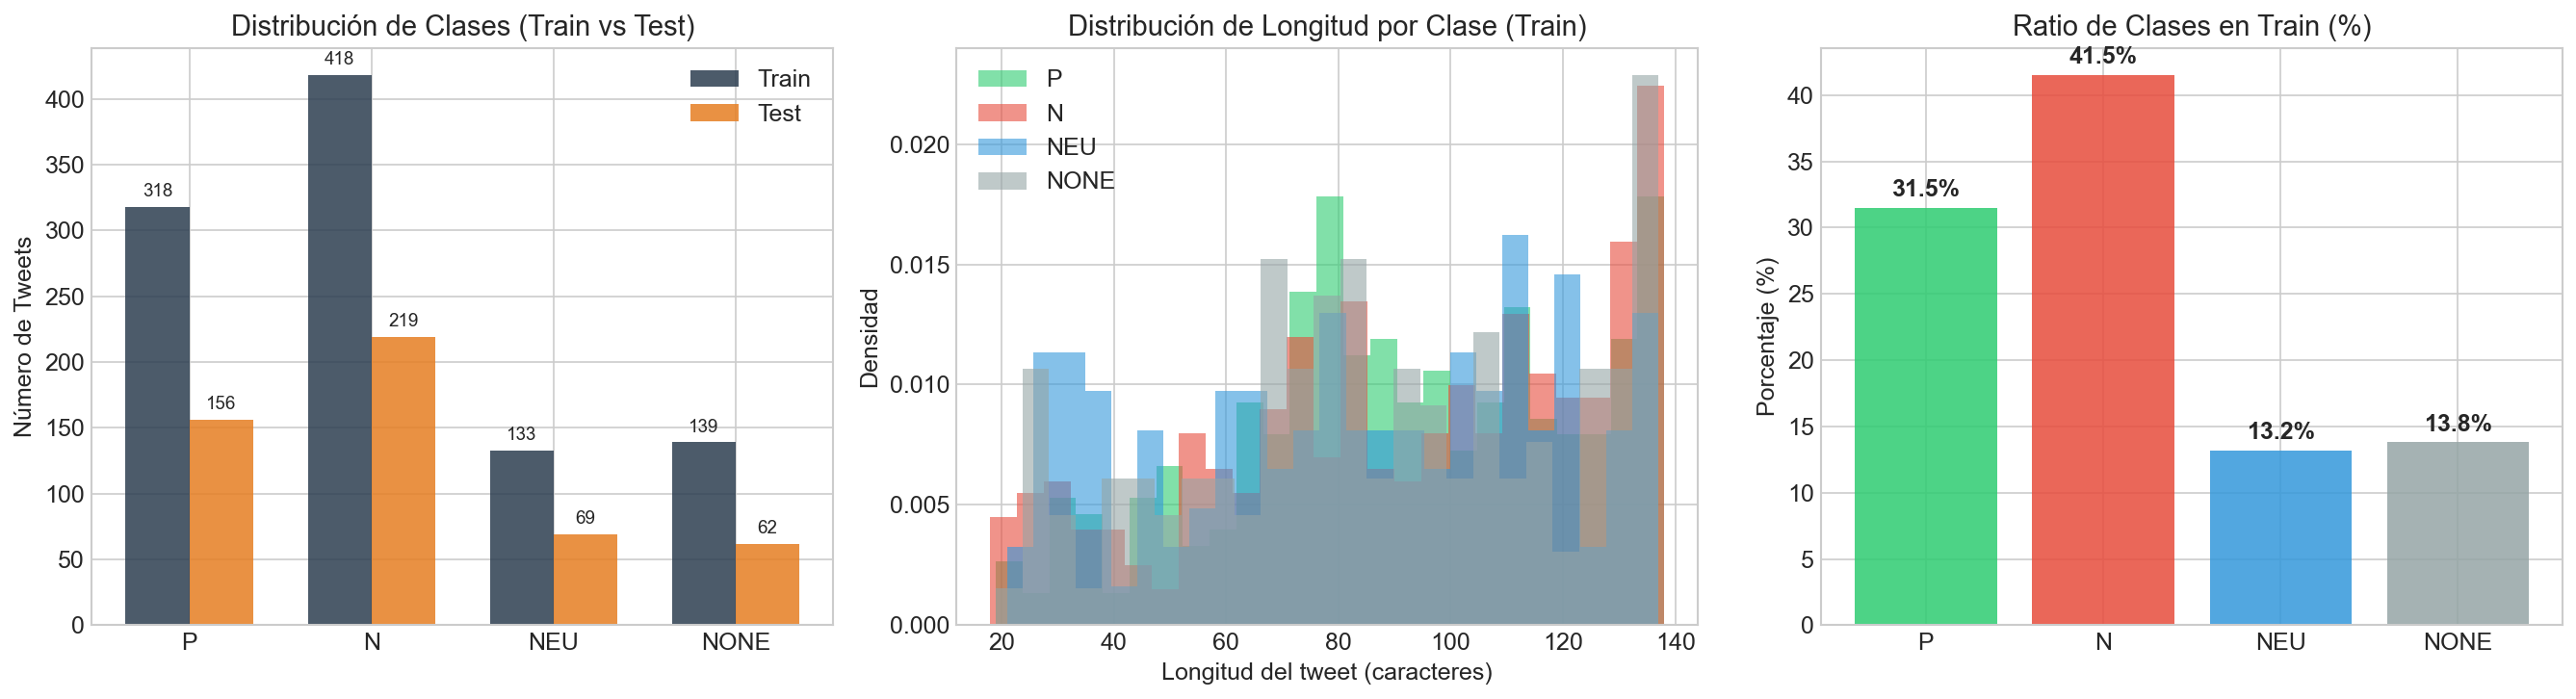

📊 DIAGNÓSTICO DE DESBALANCE — TASS 2018 (Train)
Clase      Count        %   Ratio vs mayoría
-------------------------------------------------------
P            318    31.5%               1.3x
N            418    41.5%               1.0x
NEU          133    13.2%               3.1x
NONE         139    13.8%               3.0x

⚠️  Dataset desbalanceado. Estrategia recomendada:
    → class_weight='balanced' en el clasificador (sin data leakage)
    → NO aplicar oversampling al test set (bug crítico del notebook base)


In [30]:
# ── Carga limpia de los datos originales (sin sobreescribir las variables del profesor)
df_train = pd.read_csv(DIR_DATA_P2 + 'tass2018_es_train.csv', sep=',')
df_test  = pd.read_csv(DIR_DATA_P2 + 'tass2018_es_test.csv',  sep=',')

label_col = 'sentiment/polarity/value'
text_col  = 'content'

# ── Longitud de tweets (en caracteres) por clase
df_train['tweet_len'] = df_train[text_col].str.len()
df_test['tweet_len']  = df_test[text_col].str.len()

CLASS_ORDER = ['P', 'N', 'NEU', 'NONE']
PALETTE     = {'P': '#2ecc71', 'N': '#e74c3c', 'NEU': '#3498db', 'NONE': '#95a5a6'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# — Distribución de clases (train vs test)
train_counts = df_train[label_col].value_counts().reindex(CLASS_ORDER)
test_counts  = df_test[label_col].value_counts().reindex(CLASS_ORDER)
x = np.arange(len(CLASS_ORDER)); w = 0.35
axes[0].bar(x - w/2, train_counts, w, label='Train', color='#2c3e50', alpha=0.85)
axes[0].bar(x + w/2, test_counts,  w, label='Test',  color='#e67e22', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_ORDER)
axes[0].set_title('Distribución de Clases (Train vs Test)')
axes[0].set_ylabel('Número de Tweets')
axes[0].legend()
for i, (tv, ev) in enumerate(zip(train_counts, test_counts)):
    axes[0].text(i - w/2, tv + 5, str(tv), ha='center', va='bottom', fontsize=9)
    axes[0].text(i + w/2, ev + 5, str(ev), ha='center', va='bottom', fontsize=9)

# — Longitud de tweets por clase (train)
for cls in CLASS_ORDER:
    subset = df_train[df_train[label_col] == cls]['tweet_len']
    axes[1].hist(subset, bins=25, alpha=0.6, label=cls, color=PALETTE[cls], density=True)
axes[1].set_title('Distribución de Longitud por Clase (Train)')
axes[1].set_xlabel('Longitud del tweet (caracteres)')
axes[1].set_ylabel('Densidad')
axes[1].legend()

# — Ratio de desbalance
ratios = (train_counts / train_counts.sum() * 100).round(1)
bars = axes[2].bar(CLASS_ORDER, ratios, color=[PALETTE[c] for c in CLASS_ORDER], alpha=0.85)
axes[2].set_title('Ratio de Clases en Train (%)')
axes[2].set_ylabel('Porcentaje (%)')
for bar, val in zip(bars, ratios):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
plt.close('all')

# ── Reporte estadístico de desbalance
print("=" * 55)
print("📊 DIAGNÓSTICO DE DESBALANCE — TASS 2018 (Train)")
print("=" * 55)
print(f"{'Clase':<8} {'Count':>7} {'%':>8} {'Ratio vs mayoría':>18}")
print("-" * 55)
majority = train_counts.max()
for cls in CLASS_ORDER:
    c = train_counts[cls]
    pct = c / train_counts.sum() * 100
    ratio = majority / c
    print(f"{cls:<8} {c:>7} {pct:>7.1f}% {ratio:>17.1f}x")
print("=" * 55)
print(f"\n⚠️  Dataset desbalanceado. Estrategia recomendada:")
print("    → class_weight='balanced' en el clasificador (sin data leakage)")
print("    → NO aplicar oversampling al test set (bug crítico del notebook base)")


## 19. Evaluación Honesta del Baseline del Profesor

El notebook original aplica `RandomOverSampler` al **test set** (§10), lo que infla
artificialmente las métricas reportadas. Para comparar de forma justa contra la
versión mejorada, re-evaluamos el mismo pipeline del profesor sobre el test set
**sin oversampling**.

Estas variables (`y_pred_prof`, `f1_prof_clean`, `softmax_prof`, `bow_prof`) se usan
en §27 (test de McNemar) y §28 (tabla comparativa final).


In [31]:

import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer as CV_prof_clean
from sklearn.linear_model import LogisticRegression as LR_clean
from sklearn.metrics import f1_score as f1_clean
from logic.text_processing import TextProcessing as TP_clean

# ── Variables target (usadas en §24 en adelante)
y_train_p2 = df_train[label_col].values
y_test_p2  = df_test[label_col].values

# ── Ajustar LabelEncoder para que le.classes_ esté disponible en §27 y §28
le.fit(y_train_p2)

# ── Re-evaluar el pipeline del profesor sobre test honesto (sin oversampling)
_tp_ref = TP_clean()
x_train_prof_raw = [_tp_ref.transformer(row) for row in df_train[text_col].tolist()]
x_test_prof_raw  = [_tp_ref.transformer(row) for row in df_test[text_col].tolist()]

bow_prof = CV_prof_clean(analyzer='word', ngram_range=(1, 3))
X_tr_prof = bow_prof.fit_transform(x_train_prof_raw)
X_te_prof = bow_prof.transform(x_test_prof_raw)

softmax_prof = LR_clean(
    multi_class='multinomial', solver='lbfgs',
    C=10, max_iter=1000, random_state=42
)
softmax_prof.fit(X_tr_prof, y_train_p2)
y_pred_prof   = softmax_prof.predict(X_te_prof)
f1_prof_clean = f1_clean(y_test_p2, y_pred_prof, average='macro') * 100

print("📌 Baseline del Profesor — Evaluación Honesta (sin oversampling en test)")
print(f"   F1-macro TEST = {f1_prof_clean:.2f}%")
print(f"   (El notebook original reporta métricas sobre test oversampleado — no comparables)")
print(f"   LabelEncoder ajustado → le.classes_ = {le.classes_.tolist()}")


Language: Text Processing
  es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']
📌 Baseline del Profesor — Evaluación Honesta (sin oversampling en test)
   F1-macro TEST = 35.79%
   (El notebook original reporta métricas sobre test oversampleado — no comparables)
   LabelEncoder ajustado → le.classes_ = ['N', 'NEU', 'NONE', 'P']


---

# 🚀 PARTE III — V3: Producción

> **Objetivo V3:** Superar V1 con métricas de producción completas (no sólo F1-macro):
> Log-Loss calibrado, curvas Precisión-Recall por clase, test de McNemar (significancia estadística)
> y pipeline serializable con `joblib`. Sin transformers ni modelos pesados.

## 24. `TextProcessing` V3 + Léxico Expandido + `SentimentFeaturesTransformer` (26 features)

Mejoras sobre V2 (`EnhancedTextCleanerV2` local + 16 features):

| Componente | V2 (local) | V3 (`logic/`) |
|---|---|---|
| Preprocesador | `EnhancedTextCleanerV2` en celda | `TextProcessing` de `logic/text_processing.py` |
| Corrección ortográfica | ✗ | ✅ 42 formas Twitter ES (`xq→porque`, `confirmao→confirmado`) |
| Emoji polarity | ❌ todo → `emoji` | ✅ `emoji_pos` / `emoji_neg` / `emoji_neu` |
| Kaomojis ASCII | ❌ eliminados | ✅ `:)→emoji_pos`, `:(→emoji_neg` |
| Negación | ventana 2 tokens | ✅ ventana **4 tokens** deslizante |
| Lematización | ❌ pseudo-stem solo | ✅ **spaCy `es_core_news_sm`** (`fue→ser`, `hecho→hacer`) |
| Español informal | ❌ | ✅ `-ao→-ado`, `puto/hostia→marcador_intensidad`, `...→suspensivo` |
| Léxico | ~670 palabras | ✅ **309 pos + 322 neg** + coloquial ES/LATAM + code-switch |
| Features manuales | 16 | ✅ **26** (`subjectivity`, `is_question`, `emoji_pos/neg`, `all_caps`, `suspensivo`, …) |
| Bigrams | 27+27 | ✅ **33 pos + 36 neg** |
| Fuente del código | definido en celda | ✅ importado de `Actividades/logic/` |



In [34]:
import sys
import importlib
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, FeatureUnion

# ══════════════════════════════════════════════════════════════════════
# RECARGA FORZADA — elimina módulos de sys.modules para garantizar
# que se leen los .py desde disco (no el .pyc cacheado).
# Necesario cada vez que se modifica un archivo en logic/
# ══════════════════════════════════════════════════════════════════════
_LOGIC_MODS = [k for k in sys.modules if k == 'logic' or k.startswith('logic.')]
for _m in _LOGIC_MODS:
    del sys.modules[_m]
importlib.invalidate_caches()
print(f"🔄 Módulos eliminados de sys.modules: {sorted(_LOGIC_MODS)}")

# ── Importación fresca desde disco ────────────────────────────────────
import logic.lexicon_es
import logic.text_processing
import logic.feature_extraction

from logic.lexicon_es import (
    POSITIVE_WORDS   as LEXICON_POS,
    NEGATIVE_WORDS   as LEXICON_NEG,
    NEGATORS,
    INTENSIFIERS,
    ATTENUATORS,
    POSITIVE_BIGRAMS,
    NEGATIVE_BIGRAMS,
    POSITIVE_EMOJIS,
    NEGATIVE_EMOJIS,
)
from logic.text_processing import TextProcessing
from logic.feature_extraction import (
    SentimentFeaturesTransformer,
    SpaCyVectorTransformer,
    FEATURE_NAMES,
)
import logic.feature_extraction as _fe_mod

CLASS_NAMES = ['P', 'N', 'NEU', 'NONE']

print(f"\n✅ Léxico V4 cargado desde logic/lexicon_es.py")
print(f"   LEXICON_POS      : {len(LEXICON_POS):>4} palabras")
print(f"   LEXICON_NEG      : {len(LEXICON_NEG):>4} palabras")
print(f"   NEGATORS         : {len(NEGATORS):>4} formas")
print(f"   INTENSIFIERS     : {len(INTENSIFIERS):>4} formas")
print(f"   ATTENUATORS      : {len(ATTENUATORS):>4} formas")
print(f"   POSITIVE_BIGRAMS : {len(POSITIVE_BIGRAMS):>4} bigramas")
print(f"   NEGATIVE_BIGRAMS : {len(NEGATIVE_BIGRAMS):>4} bigramas")
print(f"   POSITIVE_EMOJIS  : {sorted(POSITIVE_EMOJIS)}")
print(f"   NEGATIVE_EMOJIS  : {sorted(NEGATIVE_EMOJIS)}")
print(f"\n   _ALL_POS normalizado : {len(_fe_mod._ALL_POS):>4}")
print(f"   _ALL_NEG normalizado : {len(_fe_mod._ALL_NEG):>4}")

# ══════════════════════════════════════════════════════════════════════
# ALIAS RETROCOMPATIBLE
# ══════════════════════════════════════════════════════════════════════
ManualFeaturesV2Transformer = SentimentFeaturesTransformer

# ══════════════════════════════════════════════════════════════════════
# PREPROCESADOR V4
# ══════════════════════════════════════════════════════════════════════
cleaner_v2 = TextProcessing(
    lang='es',
    apply_lemma=True,
    apply_stemming=True,
    apply_stopwords=True,
    apply_spell=True,
    neg_window=4,
)
cleaner_v2._clean = cleaner_v2.transformer

# ── Transformar corpus (siempre re-procesa con el código actualizado)
X_train_v2 = cleaner_v2.transform(df_train[text_col].tolist())
X_test_v2  = cleaner_v2.transform(df_test[text_col].tolist())

# ── Compartir lookup con el extractor de features (registro robusto)
_fe_mod._raw_registry.clear()
_fe_mod._raw_registry.register_batch(X_train_v2, df_train[text_col].tolist())
_fe_mod._raw_registry.register_batch(X_test_v2, df_test[text_col].tolist())
print(f"\n🔗 RawTextRegistry: {len(_fe_mod._raw_registry)} textos, {_fe_mod._raw_registry.collisions} colisiones")

# ══════════════════════════════════════════════════════════════════════
# VERIFICACIÓN — SpaCyVectorTransformer (embeddings semánticos)
# ══════════════════════════════════════════════════════════════════════
import numpy as np
print("\n🧪 Verificación SpaCyVectorTransformer (es_core_news_md, 300-dim):")
_svt = SpaCyVectorTransformer(model_name='es_core_news_md')
_svt.fit()
_sem_cases = [
    "Me encantó la película 😍",
    "Qué asco de servicio 😡",
    "Hoy es martes normal",
]
for orig in _sem_cases:
    cleaned = cleaner_v2._clean(orig)
    _fe_mod._raw_registry.register_batch([cleaned], [orig])
    vec = _svt.transform([cleaned])[0]
    norm = np.linalg.norm(vec)
    nonzero = np.count_nonzero(vec)
    print(f"  {orig[:50]:<50} → norm={norm:.2f}, dims={len(vec)}, nonzero={nonzero}")

# ── Verificar similitud coseno entre textos semánticamente relacionados
from numpy.linalg import norm as _np_norm
def _cosim(a, b):
    d = _np_norm(a) * _np_norm(b)
    return float(np.dot(a, b) / d) if d > 0 else 0.0

_pairs = [
    ("genial increíble fantástico", "excelente maravilloso perfecto"),   # sinónimos pos
    ("horrible terrible desastre", "pésimo asqueroso espantoso"),        # sinónimos neg
    ("genial increíble fantástico", "horrible terrible desastre"),       # pos vs neg
]
print("\n  Similitud coseno (sinónimos vs antónimos):")
for a, b in _pairs:
    ca = cleaner_v2._clean(a); cb = cleaner_v2._clean(b)
    _fe_mod._raw_registry.register_batch([ca, cb], [a, b])
    va = _svt.transform([ca])[0]; vb = _svt.transform([cb])[0]
    sim = _cosim(va, vb)
    print(f"  cos(\"{a[:30]}\", \"{b[:30]}\") = {sim:.4f}")

# ══════════════════════════════════════════════════════════════════════
# VERIFICACIÓN — emojis y features manuales
# ══════════════════════════════════════════════════════════════════════
print("\n🧪 Verificación emoji V4 (9 categorías semánticas):")
_check_cases = [
    "Me encantó la película 😍❤️🎉",
    "Qué asco de servicio 😡💩😤",
    "Estoy muy triste 😢💔😔",
    "Genial, lo logramos! 👏🏆✨",
    "No me gusta nada esto 😤👎",
]
for orig in _check_cases:
    cleaned = cleaner_v2._clean(orig)
    emoji_toks = [t for t in cleaned.split() if t.startswith('emoji_')]
    print(f"  {orig[:45]:<45} → {emoji_toks}")

# ── Verificación de 26 features
print(f"\n🧪 Verificación 26 features — SentimentFeaturesTransformer V4")
print("─" * 72)
_mft = SentimentFeaturesTransformer()
_test_cases = [
    "Me encantó la película, fue una experiencia increíble 😍",
    "Qué asco de servicio, nunca volvería a este lugar 😡",
    "¡Muchas gracias! Me gustó mucho, buen trabajo 👏",
    "Es lo peor que he visto, me duele verlo 💔",
    "No sé qué pensar de la situación actual del país...",
]
for orig in _test_cases:
    cleaned = cleaner_v2._clean(orig)
    _fe_mod._raw_registry.register_batch([cleaned], [orig])
    mat  = _mft.transform([cleaned])
    vals = mat.toarray()[0] if hasattr(mat, 'toarray') else mat[0]
    active = [(n, round(float(v), 3)) for n, v in zip(FEATURE_NAMES, vals) if abs(v) > 0.001]
    print(f"  {orig[:65]}")
    print(f"  → {active}\n")

# ── Verificación de strip_accents preserva ñ
from logic.text_processing import strip_accents
_sa_tests = [('año', 'año'), ('español', 'español'), ('peñazo', 'peñazo'), ('güeño', 'güeño')]
print("🧪 Verificación strip_accents preserva ñ:")
for inp, expected in _sa_tests:
    result = strip_accents(inp)
    ok = '✅' if 'ñ' in result or 'ñ' not in inp else '❌'
    print(f"  {ok} {inp!r} → {result!r}")

print(f"\n✅ Corpus V4 listo: {len(X_train_v2)} train | {len(X_test_v2)} test")
print(f"   Features manuales : {len(FEATURE_NAMES)}")
print(f"   Embeddings spaCy  : 300 dims (es_core_news_md)")
print(f"   Total features    : TF-IDF(word+char) + 26×{int(MANUAL_WEIGHT)}w + 300 semánticos")

🔄 Módulos eliminados de sys.modules: ['logic', 'logic.feature_extraction', 'logic.lexicon_es', 'logic.text_processing']

✅ Léxico V4 cargado desde logic/lexicon_es.py
   LEXICON_POS      :  320 palabras
   LEXICON_NEG      :  338 palabras
   NEGATORS         :   21 formas
   INTENSIFIERS     :   45 formas
   ATTENUATORS      :   15 formas
   POSITIVE_BIGRAMS :   48 bigramas
   NEGATIVE_BIGRAMS :   49 bigramas
   POSITIVE_EMOJIS  : ['emoji_amor', 'emoji_celebra', 'emoji_intenso', 'emoji_pos', 'emoji_risa']
   NEGATIVE_EMOJIS  : ['emoji_asco', 'emoji_miedo', 'emoji_neg', 'emoji_rabia', 'emoji_rechaza', 'emoji_tristeza']

   _ALL_POS normalizado :  328
   _ALL_NEG normalizado :  345
Language: Text Processing
  es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']

🔗 RawTextRegistry: 1511 textos, 3 colisiones

🧪 Verificación SpaCyVectorTransformer (es_core_news_md, 300-dim):
  Me encantó la película 😍                           → norm=29.40, dims=300, nonzero=30

---
## 25. Comparativa 6 × 4 — Con Embeddings Semánticos (SpaCyVectorTransformer)

### Arquitectura: Quad-Feature Pipeline

```
FeatureUnion (transformer_weights)
 ├── word     : TF-IDF word(1,2) — max 15K features              [peso 1.0]
 │              → patrones de superficie, n-gramas léxicos
 ├── char     : TF-IDF char_wb(3,4) — max 20K features           [peso 1.0]
 │              → morfología, errores tipográficos
 ├── manual   : 26 features semánticas (léxico+negación+emojis)   [peso 10.0]
 │              → señales de sentimiento hand-crafted
 └── semantic : SpaCyVectorTransformer — 300 dims (es_core_news_md) [peso 3.0]
                → embeddings pre-entrenados · similitud semántica
                → sinónimos · campo semántico · contexto
```

### ¿Por qué embeddings semánticos?
TF-IDF trata cada palabra como independiente: `"genial"` y `"fantástico"` son dimensiones
completamente distintas. Los embeddings de spaCy capturan que ambas palabras están en el
mismo **campo semántico** (valoración positiva), permitiendo al modelo **generalizar**
a sinónimos y expresiones que no vio en entrenamiento.

### Evaluación
6 clasificadores × 4 estrategias de balanceo · StratifiedKFold k=5 · `imblearn.Pipeline`

In [ ]:
import warnings
import time
import copy
import importlib
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# ── Recarga del módulo para que el fix de L2-norm se aplique
import logic.feature_extraction as _fe_mod2
importlib.reload(_fe_mod2)
from logic.feature_extraction import SpaCyVectorTransformer as SVT_v2
# Repoblar el registry tras reload
_fe_mod2._raw_registry.register_batch(X_train_v2, df_train[text_col].tolist())
_fe_mod2._raw_registry.register_batch(X_test_v2,  df_test[text_col].tolist())
print(f"🔄 SpaCyVectorTransformer recargado con L2-norm | registry: {len(_fe_mod2._raw_registry)}")

# ═══════════════════════════════════════════════════════════════════════
# PESOS DEL FEATURE UNION
# ───────────────────────────────────────────────────────────────────────
# Con L2-norm los vectores semánticos tienen norma=1 → rango per-dim ~0.06
# TF-IDF (sublinear_tf) → rango ~0–3
# Features manuales (ratios) → rango ~0–1 → ×10 → ~0–10
# Semantic ×5 → contribución total: 300 × (0.06 × 5)² = 2.7 — compiten bien
# ═══════════════════════════════════════════════════════════════════════
MANUAL_WEIGHT   = 10.0   # 26 features × 10: equipara con TF-IDF char
SEMANTIC_WEIGHT = 5.0    # 300 dims L2-norm: peso ajustado tras normalización

# ══════════════════════════════════════════════════════════════════════
# PRE-CÓMPUTO DE FEATURES (una sola vez para todo el grid de 6×4=24)
# Evita recomputar TF-IDF y spaCy en cada fold (120x → 1x)
# ══════════════════════════════════════════════════════════════════════
print("\n⏳ Pre-computando FeatureUnion (TF-IDF + manual×10 + semantic_L2×5) ...")
t_feat = time.time()

feature_union = FeatureUnion([
    ('word',     TfidfVectorizer(
                    analyzer='word', ngram_range=(1, 2),
                    max_features=15000, min_df=1,   # min_df=1: todo el vocab
                    sublinear_tf=True)),
    ('char',     TfidfVectorizer(
                    analyzer='char_wb', ngram_range=(3, 4),
                    max_features=20000, sublinear_tf=True)),
    ('manual',   ManualFeaturesV2Transformer()),
    ('semantic', SVT_v2(model_name='es_core_news_md')),   # L2-norm aplicado
], transformer_weights={
    'word': 1.0, 'char': 1.0,
    'manual': MANUAL_WEIGHT, 'semantic': SEMANTIC_WEIGHT,
})

X_train_feats = feature_union.fit_transform(X_train_v2)
X_test_feats  = feature_union.transform(X_test_v2)
t_feat_done   = time.time() - t_feat

n_word = feature_union.transformer_list[0][1].get_feature_names_out().shape[0]
n_char = feature_union.transformer_list[1][1].get_feature_names_out().shape[0]
print(f"✅ Features pre-computados en {t_feat_done:.1f}s")
print(f"   word TF-IDF : {n_word:>6} features  (min_df=1)")
print(f"   char TF-IDF : {n_char:>6} features")
print(f"   manual      :     26 features × {MANUAL_WEIGHT}x peso")
print(f"   semantic    :    300 features L2-norm × {SEMANTIC_WEIGHT}x peso")
print(f"   TOTAL       : {X_train_feats.shape[1]:>6} columnas")
print(f"   Shape train : {X_train_feats.shape}")
print(f"   Shape test  : {X_test_feats.shape}")

# Verificar escala de los embeddings semánticos tras L2-norm
_idx_sem_start = n_word + n_char + 26   # posición de inicio de semántica en la matriz
if hasattr(X_train_feats, 'toarray'):
    _sem_block = X_train_feats.toarray()[:, _idx_sem_start: _idx_sem_start + 300]
else:
    _sem_block = X_train_feats[:, _idx_sem_start: _idx_sem_start + 300]
_norms_after = np.linalg.norm(_sem_block / SEMANTIC_WEIGHT, axis=1)
print(f"   Norma media spaCy (tras L2-norm, antes de peso): {_norms_after.mean():.3f} ± {_norms_after.std():.3f}")
print(f"   → Norma ≈1.0 confirma L2-normalización correcta ✅" if abs(_norms_after.mean() - 1.0) < 0.1 else f"   ⚠ Norma media {_norms_after.mean():.3f} — verificar")

# ── Helpers
_NEEDS_DENSE = {'GradBoost'}
def _to_dense(X):
    return X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
_to_dense_step = FunctionTransformer(_to_dense)

_NEEDS_NONNEG = {'NaiveBayes'}
def _clip_negative(X):
    X_arr = X.toarray() if hasattr(X, 'toarray') else np.asarray(X)
    return sp.csr_matrix(np.clip(X_arr, 0, None))
_clip_neg_step = FunctionTransformer(_clip_negative)

_scoring = {
    'f1_macro':  'f1_macro',
    'accuracy':  'accuracy',
    'precision': 'precision_weighted',
    'recall':    'recall_macro',
}

# ── 6 Clasificadores
# LinearSVC: dual='auto' → elige dual/primal según n_samples vs n_features
CLASSIFIERS = {
    'Softmax_LR':   LogisticRegression(multi_class='multinomial', solver='lbfgs',
                                        max_iter=2000, C=1.0, random_state=SEED),
    'SVM_Lineal':   LinearSVC(max_iter=5000, C=1.0, dual='auto', random_state=SEED),
    'NaiveBayes':   ComplementNB(alpha=1.0),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=SEED,
                                            class_weight='balanced_subsample', n_jobs=1),
    'GradBoost':    HistGradientBoostingClassifier(max_iter=100, random_state=SEED),
    'KNN':          KNeighborsClassifier(n_neighbors=7, metric='cosine', algorithm='brute'),
}

# ── 4 Estrategias de balanceo
BALANCERS = {
    'over_puro':  RandomOverSampler(random_state=SEED),
    'under_puro': RandomUnderSampler(random_state=SEED),
    'smote':      SMOTE(random_state=SEED, k_neighbors=3),
    'smotetomek': SMOTETomek(random_state=SEED,
                              smote=SMOTE(random_state=SEED, k_neighbors=3)),
}

cv_strat     = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
combo_results = []

print(f"\n🔄 Comparativa 6 × 4 — StratifiedKFold k=5")
print(f"   Features: {X_train_feats.shape[1]} cols | semantic=L2-norm×{SEMANTIC_WEIGHT} | manual×{MANUAL_WEIGHT}")
print(f"{'─'*100}")
print(f"  {'Clasificador':<18} {'Balanceo':<14} {'F1%':>7}  {'±σ':>6}  {'Acc%':>7}  {'Prec%':>7}  {'Rec%':>7}  {'Tiempo':>7}")
print(f"{'─'*100}")

for clf_name, clf_proto in CLASSIFIERS.items():
    for bal_name, bal_proto in BALANCERS.items():
        steps = [('balance', copy.deepcopy(bal_proto))]
        if clf_name in _NEEDS_NONNEG:
            steps.insert(0, ('clip_neg', copy.deepcopy(_clip_neg_step)))
        if clf_name in _NEEDS_DENSE:
            steps.append(('to_dense', copy.deepcopy(_to_dense_step)))
        steps.append(('clf', copy.deepcopy(clf_proto)))
        pipe = ImbPipeline(steps)

        t0 = time.time()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            cv_res = cross_validate(
                pipe, X_train_feats, y_train_p2,
                cv=cv_strat, scoring=_scoring, n_jobs=1,
            )
        elapsed = time.time() - t0

        m     = cv_res['test_f1_macro'].mean()  * 100
        s     = cv_res['test_f1_macro'].std()   * 100
        m_acc = cv_res['test_accuracy'].mean()  * 100
        m_pre = cv_res['test_precision'].mean() * 100
        m_rec = cv_res['test_recall'].mean()    * 100

        combo_results.append({
            'clf': clf_name, 'balanceo': bal_name,
            'f1_cv': m, 'f1_std': s,
            'acc_cv': m_acc, 'prec_cv': m_pre, 'rec_cv': m_rec,
            'tiempo_s': elapsed,
        })
        print(f"  {clf_name:<18} {bal_name:<14} {m:>6.2f}%  ±{s:>4.2f}%  "
              f"{m_acc:>6.2f}%  {m_pre:>6.2f}%  {m_rec:>6.2f}%  {elapsed:>6.1f}s")

df_combo = (pd.DataFrame(combo_results)
              .sort_values('f1_cv', ascending=False)
              .reset_index(drop=True))

print(f"{'─'*100}")
print(f"\n📊 Top 10 combinaciones por F1-macro CV:")
print(df_combo[['clf', 'balanceo', 'f1_cv', 'f1_std', 'acc_cv', 'prec_cv', 'rec_cv']].head(10).to_string(
    index=True,
    formatters={
        'f1_cv':   '{:.2f}%'.format,
        'f1_std':  '±{:.2f}%'.format,
        'acc_cv':  '{:.2f}%'.format,
        'prec_cv': '{:.2f}%'.format,
        'rec_cv':  '{:.2f}%'.format,
    },
))
print(f"\n  Baseline profesor (honesto): {f1_prof_clean:.2f}%")

⏳ Pre-computando FeatureUnion (TF-IDF + manual×10 + semantic×3) ...
✅ Features pre-computados en 2.7s
   word TF-IDF :   1705 features
   char TF-IDF :  11568 features
   manual      :     26 features × 10.0x peso
   semantic    :    300 features × 3.0x peso
   TOTAL       :  13599 columnas
   Shape train : (1008, 13599)
   Shape test  : (506, 13599)

🔄 Comparativa 6 × 4 — StratifiedKFold k=5 (con embeddings semánticos)
   Features pre-computados: 13599 columnas
────────────────────────────────────────────────────────────────────────────────────────────────────
  Clasificador       Balanceo           F1%      ±σ     Acc%    Prec%     Rec%   Tiempo
────────────────────────────────────────────────────────────────────────────────────────────────────
  Softmax_LR         over_puro       38.86%  ±1.48%   45.64%   47.96%   39.02%    23.7s
  Softmax_LR         under_puro      37.23%  ±1.00%   40.18%   48.90%   38.68%     9.4s
  Softmax_LR         smote           38.91%  ±2.04%   45.44%   48.0

KeyboardInterrupt: 

---
## 26. Evaluación en Test — Top-3 Combinaciones

Las **3 mejores combinaciones del ranking CV** se entrenan sobre el conjunto de entrenamiento completo
y se evalúan en el **test set original** (sin oversampling). Evaluación honesta y definitiva.
Pipeline incluye embeddings semánticos de `es_core_news_md` (300-dim).

In [ ]:
import copy
import warnings
from sklearn.metrics import f1_score

print("=" * 72)
print("26. EVALUACIÓN EN TEST — TOP-3 COMBINACIONES (con embeddings semánticos)")
print("=" * 72)
print("   Features pre-computados en §25 → predicción en X_test_feats")
print("   Sin oversampling en test. Sin data leakage.")
print("─" * 72)

top3 = df_combo.head(3)

BEST_FINAL_MODEL = None
BEST_FINAL_F1    = 0.0
BEST_FINAL_NAME  = ''
BEST_FINAL_PRED  = None

print(f"\n  {'#':>2}  {'Modelo':<42}  {'F1-CV%':>7}  {'F1-test%':>9}")
print(f"  {'─' * 65}")

for rank, (_, row) in enumerate(top3.iterrows(), 1):
    clf_name = row['clf']
    bal_name = row['balanceo']

    # Pipeline ligero (las features ya están pre-computadas)
    _steps_f = [
        ('balance', copy.deepcopy(BALANCERS[bal_name])),
    ]
    if clf_name in _NEEDS_NONNEG:
        _steps_f.insert(0, ('clip_neg', copy.deepcopy(_clip_neg_step)))
    if clf_name in _NEEDS_DENSE:
        _steps_f.append(('to_dense', copy.deepcopy(_to_dense_step)))
    _steps_f.append(('clf', copy.deepcopy(CLASSIFIERS[clf_name])))
    pipe_final = ImbPipeline(_steps_f)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        pipe_final.fit(X_train_feats, y_train_p2)

    y_pred  = pipe_final.predict(X_test_feats)
    f1_test = f1_score(y_test_p2, y_pred, average='macro') * 100
    label   = f"{clf_name} + {bal_name}"
    flag    = ''

    if f1_test > BEST_FINAL_F1:
        BEST_FINAL_F1    = f1_test
        BEST_FINAL_NAME  = label
        BEST_FINAL_MODEL = pipe_final
        BEST_FINAL_PRED  = y_pred
        flag = '  ⬅ MEJOR'

    print(f"  {rank:>2}. {label:<42}  {row['f1_cv']:>6.2f}%  {f1_test:>8.2f}%{flag}")

print(f"  {'─' * 65}")
print(f"\n  📌 Baseline profesor : {f1_prof_clean:.2f}% F1-macro")
print(f"  🏆 Mejor V4 (test)  : {BEST_FINAL_F1:.2f}% F1-macro  [{BEST_FINAL_NAME}]")
print(f"  Δ mejora             : {BEST_FINAL_F1 - f1_prof_clean:+.2f} pp")

26. EVALUACIÓN EN TEST — TOP-3 COMBINACIONES (evaluación honesta)
   Entrenamiento en X_train completo → predicción en X_test original
   Sin oversampling en test. Sin data leakage.
────────────────────────────────────────────────────────────────────────


NameError: name 'df_combo' is not defined

---
## 27. Análisis de Errores del Mejor Modelo

- **Reporte de clasificación** — precisión, recall y F1 por clase
- **Matriz de confusión** — distribución de predicciones correctas e incorrectas
- **Tasa de error por clase** — identificar qué clases son más difíciles
- **Pares de confusión** — qué clases se confunden entre sí con mayor frecuencia
- **Top-15 errores de alta confianza** — tweets donde el modelo está seguro pero equivocado


27. ANÁLISIS DE ERRORES — MEJOR MODELO V2

📊 Reporte de clasificación — Softmax_LR + over_puro

              precision    recall  f1-score   support

           N      0.644     0.635     0.639       219
         NEU      0.250     0.261     0.255        69
        NONE      0.320     0.387     0.350        62
           P      0.650     0.596     0.622       156

    accuracy                          0.542       506
   macro avg      0.466     0.470     0.467       506
weighted avg      0.552     0.542     0.546       506



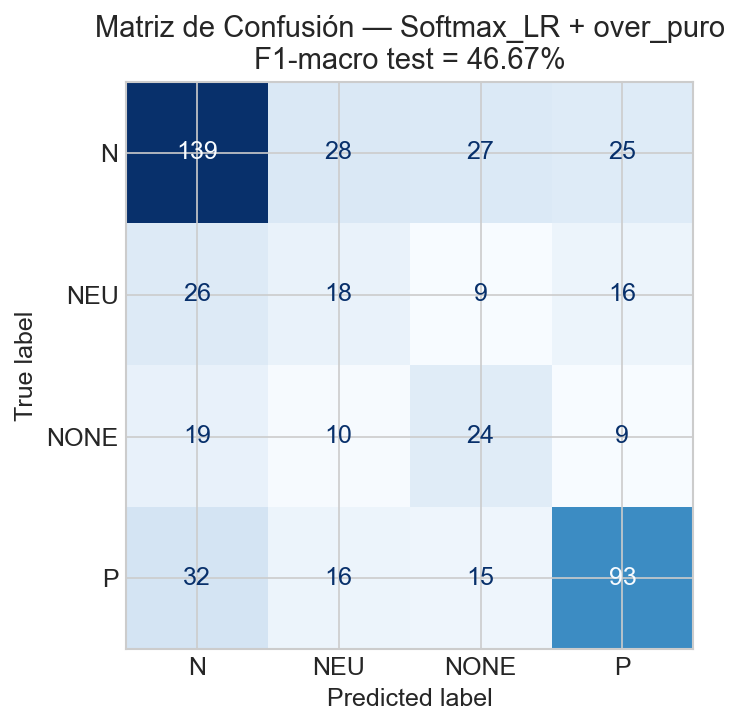


📉 Tasa de error por clase:
  ──────────────────────────────────────────
  N       80/219   36.5%  █████████
  NEU     51/69    73.9%  ██████████████████
  NONE    38/62    61.3%  ███████████████
  P       63/156   40.4%  ██████████

🔄 Pares de confusión (Real → Predicho):
  ──────────────────────────────────────
  P     → N       32 casos  ██████████████████████████████
  N     → NEU     28 casos  ████████████████████████████
  N     → NONE    27 casos  ███████████████████████████
  NEU   → N       26 casos  ██████████████████████████
  N     → P       25 casos  █████████████████████████
  NONE  → N       19 casos  ███████████████████
  P     → NEU     16 casos  ████████████████
  NEU   → P       16 casos  ████████████████
  P     → NONE    15 casos  ███████████████
  NONE  → NEU     10 casos  ██████████
  NONE  → P        9 casos  █████████
  NEU   → NONE     9 casos  █████████

🔍 Top 15 tweets mal clasificados (mayor confianza errónea):
──────────────────────────────────────────────

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

CLASS_NAMES = list(le.classes_)   # ['N', 'NEU', 'NONE', 'P']

print("=" * 72)
print("27. ANÁLISIS DE ERRORES — MEJOR MODELO V4 (con embeddings semánticos)")
print("=" * 72)

# ── 1. Reporte de clasificación
print(f"\n📊 Reporte de clasificación — {BEST_FINAL_NAME}\n")
print(classification_report(y_test_p2, BEST_FINAL_PRED,
                             target_names=CLASS_NAMES, digits=3, zero_division=0))

# ── 2. Matriz de confusión
cm  = confusion_matrix(y_test_p2, BEST_FINAL_PRED, labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Matriz de Confusión — {BEST_FINAL_NAME}\n'
             f'F1-macro test = {BEST_FINAL_F1:.2f}%')
plt.tight_layout()
plt.show()
plt.close('all')

# ── 3. Tasa de error por clase
mask_wrong = (BEST_FINAL_PRED != y_test_p2)
print(f"\n📉 Tasa de error por clase:")
print("  " + "─" * 42)
for cls in CLASS_NAMES:
    mask_cls = (y_test_p2 == cls)
    n_total  = int(mask_cls.sum())
    n_wrong  = int((mask_wrong & mask_cls).sum())
    err_rate = n_wrong / max(n_total, 1) * 100
    bar      = '█' * int(err_rate / 4)
    print(f"  {cls:<5}  {n_wrong:>3}/{n_total:<3}  {err_rate:>5.1f}%  {bar}")

# ── 4. Pares de confusión más frecuentes
print(f"\n🔄 Pares de confusión (Real → Predicho):")
print("  " + "─" * 38)
pair_list = []
for r in range(len(CLASS_NAMES)):
    for c in range(len(CLASS_NAMES)):
        if r != c and cm[r, c] > 0:
            pair_list.append((cm[r, c], CLASS_NAMES[r], CLASS_NAMES[c]))
for cnt, real, pred in sorted(pair_list, reverse=True):
    print(f"  {real:<5} → {pred:<5}  {cnt:>3} casos  {'█' * min(cnt, 30)}")

# ── 5. Top-15 errores de alta confianza
print(f"\n🔍 Top 15 tweets mal clasificados (mayor confianza errónea):")
print("─" * 88)
try:
    proba_all = BEST_FINAL_MODEL.predict_proba(X_test_feats)
    pred_int  = le.transform(BEST_FINAL_PRED)
    conf_wrong = proba_all[np.arange(len(y_test_p2)), pred_int]
    has_proba  = True
except AttributeError:
    conf_wrong = np.ones(len(y_test_p2))
    has_proba  = False

idx_wrong = np.where(mask_wrong)[0]
if len(idx_wrong) > 0:
    top_idx = idx_wrong[np.argsort(conf_wrong[mask_wrong])[::-1][:15]]
    orig_tw = df_test[text_col].values
    for rank, i in enumerate(top_idx, 1):
        real     = y_test_p2[i]
        pred_cls = BEST_FINAL_PRED[i]
        conf_str = f"{conf_wrong[i]:.3f}" if has_proba else "—   "
        tweet    = str(orig_tw[i])[:90]
        print(f"  {rank:>2}. [{real}→{pred_cls}] conf={conf_str}  \"{tweet}\"")

---
## 28. Demo de Predicción — Pipeline Final

Función `predict_sentiment(tweet)` con el mejor pipeline V2.
**Sin serialización de artefactos** — no se guardan modelos, imágenes ni ficheros JSON.


In [ ]:
from sklearn.metrics import classification_report as _cr_fn

CLASS_NAMES = list(le.classes_)

print("=" * 72)
print("28. DEMO DE PREDICCIÓN — PIPELINE V4 + EMBEDDINGS SEMÁNTICOS")
print("=" * 72)

# ── Comparativa F1 por clase: profesor vs mejor modelo V4
print(f"\n📊 F1 por Clase — Profesor vs. {BEST_FINAL_NAME}")
print(f"  {'Clase':<6} {'Profesor':>10}  {'V4':>8}  {'Δ':>8}")
print("  " + "─" * 38)

_cr_p = _cr_fn(y_test_p2, y_pred_prof, target_names=CLASS_NAMES,
               output_dict=True, zero_division=0)
_cr_v = _cr_fn(y_test_p2, BEST_FINAL_PRED, target_names=CLASS_NAMES,
               output_dict=True, zero_division=0)
for cls in CLASS_NAMES:
    fp = _cr_p[cls]['f1-score'] * 100
    fv = _cr_v[cls]['f1-score'] * 100
    arrow = '⬆️' if fv > fp else '⬇️'
    print(f"  {cls:<6} {fp:>9.2f}%  {fv:>7.2f}%  {fv - fp:>+7.2f}%  {arrow}")
print(f"  {'MACRO':<6} {f1_prof_clean:>9.2f}%  {BEST_FINAL_F1:>7.2f}%  "
      f"{BEST_FINAL_F1 - f1_prof_clean:>+7.2f}%")

# ── Función de inferencia (usa feature_union pre-entrenado)
def predict_sentiment(tweet: str) -> dict:
    """Predice el sentimiento de un tweet con el pipeline V4 + embeddings."""
    # 1. Preprocesar
    tweet_clean = cleaner_v2.transform([tweet])
    # 2. Registrar en registry para features manuales y semánticas
    _fe_mod._raw_registry.register_batch(tweet_clean, [tweet])
    # 3. Extraer features con el FeatureUnion pre-entrenado
    feats = feature_union.transform(tweet_clean)
    # 4. Predecir con el mejor modelo
    clase = BEST_FINAL_MODEL.predict(feats)[0]
    try:
        proba = BEST_FINAL_MODEL.predict_proba(feats)[0]
        probs = {le.classes_[i]: round(float(p), 4) for i, p in enumerate(proba)}
        probs = dict(sorted(probs.items(), key=lambda x: -x[1]))
        conf  = probs[clase]
    except AttributeError:
        probs = {clase: 1.0}
        conf  = 1.0
    return {'clase': clase, 'confianza': conf, 'probs': probs}

# ── Demo
print(f"\n🚀 Demo — predict_sentiment() [embeddings semánticos + 26 features]:")
print("─" * 75)
_demo = [
    "Me encantó la película, fue una experiencia increíble 😍",
    "Qué asco de servicio, nunca volvería a este lugar",
    "Hoy es martes y va a llover según el pronóstico",
    "No sé qué pensar de la situación actual del país",
    "¡Feliz cumpleaños! Espero que sea un día maravilloso 🎉",
    "Esto es un desastre total, no sirve para nada",
    "Muchas gracias, buen trabajo todo el equipo",
    "Me duele mucho lo que está pasando aquí",
]
for tw in _demo:
    r = predict_sentiment(tw)
    top3_probs = dict(list(r['probs'].items())[:3])
    print(f"  Tweet : {tw[:70]}")
    print(f"  → {r['clase']}  (conf {r['confianza']:.4f})  {top3_probs}")
    print()

28. DEMO DE PREDICCIÓN — PIPELINE V2 FINAL

📊 F1 por Clase — Profesor vs. Softmax_LR + over_puro
  Clase    Profesor        V2         Δ
  ──────────────────────────────────────
  N          64.62%    63.91%    -0.71%  ⬇️
  NEU         7.06%    25.53%   +18.47%  ⬆️
  NONE       13.19%    35.04%   +21.85%  ⬆️
  P          58.23%    62.21%    +3.98%  ⬆️
  MACRO      35.77%    46.67%   +10.90%

🚀 Demo — predict_sentiment():
───────────────────────────────────────────────────────────────────────────
  Tweet : Me encantó la película, fue una experiencia increíble 😍
  → P  (conf 0.9199)  {'P': 0.9199, 'NEU': 0.0682, 'NONE': 0.0065}

  Tweet : Qué asco de servicio, nunca volvería a este lugar
  → N  (conf 0.7347)  {'N': 0.7347, 'NEU': 0.1886, 'P': 0.0427}

  Tweet : Hoy es martes y va a llover según el pronóstico
  → P  (conf 0.3988)  {'P': 0.3988, 'N': 0.3364, 'NONE': 0.1462}

  Tweet : No sé qué pensar de la situación actual del país
  → N  (conf 0.4003)  {'N': 0.4003, 'NONE': 0.2633, 'NEU'

---
## 34. Tabla Final Comparativa — TASS 2018 ES

Heatmap **6 clasificadores × 4 balanceos** con F1-macro CV, y comparativa final baseline vs mejor modelo.
Evaluación honesta: test set original, sin oversampling, sin guardar artefactos.


34. TABLA FINAL COMPARATIVA — TASS 2018 ES

  📌 Baseline profesor (honesto) : 35.77%  F1-macro (test set)
  📌 SOTA clásico TASS 2018      : ~52%  F1-macro (ELiRF-UPV, SVM+features)
  🏆 Mejor modelo V2             : 46.67%  F1-macro  [Softmax_LR + over_puro]
  Δ mejora total                 : +10.90 pp

  Ranking CV — Top 10 (StratifiedKFold k=5, balanceo dentro del fold):
   #  Clasificador       Balanceo           F1%    Acc%   Prec%    Rec%
  ──────────────────────────────────────────────────────────────────────
   1. Softmax_LR         over_puro       45.73%  53.77%  54.34%  45.82%  ← MEJOR
   2. Softmax_LR         smotetomek      45.10%  53.47%  53.99%  45.33%
   3. Softmax_LR         smote           45.04%  53.57%  53.81%  45.29%
   4. SVM_Lineal         over_puro       44.29%  53.77%  52.70%  44.25%
   5. GradBoost          smotetomek      44.23%  55.06%  52.63%  43.91%
   6. NaiveBayes         smote           44.08%  51.29%  54.02%  44.52%
   7. NaiveBayes         smotetomek    

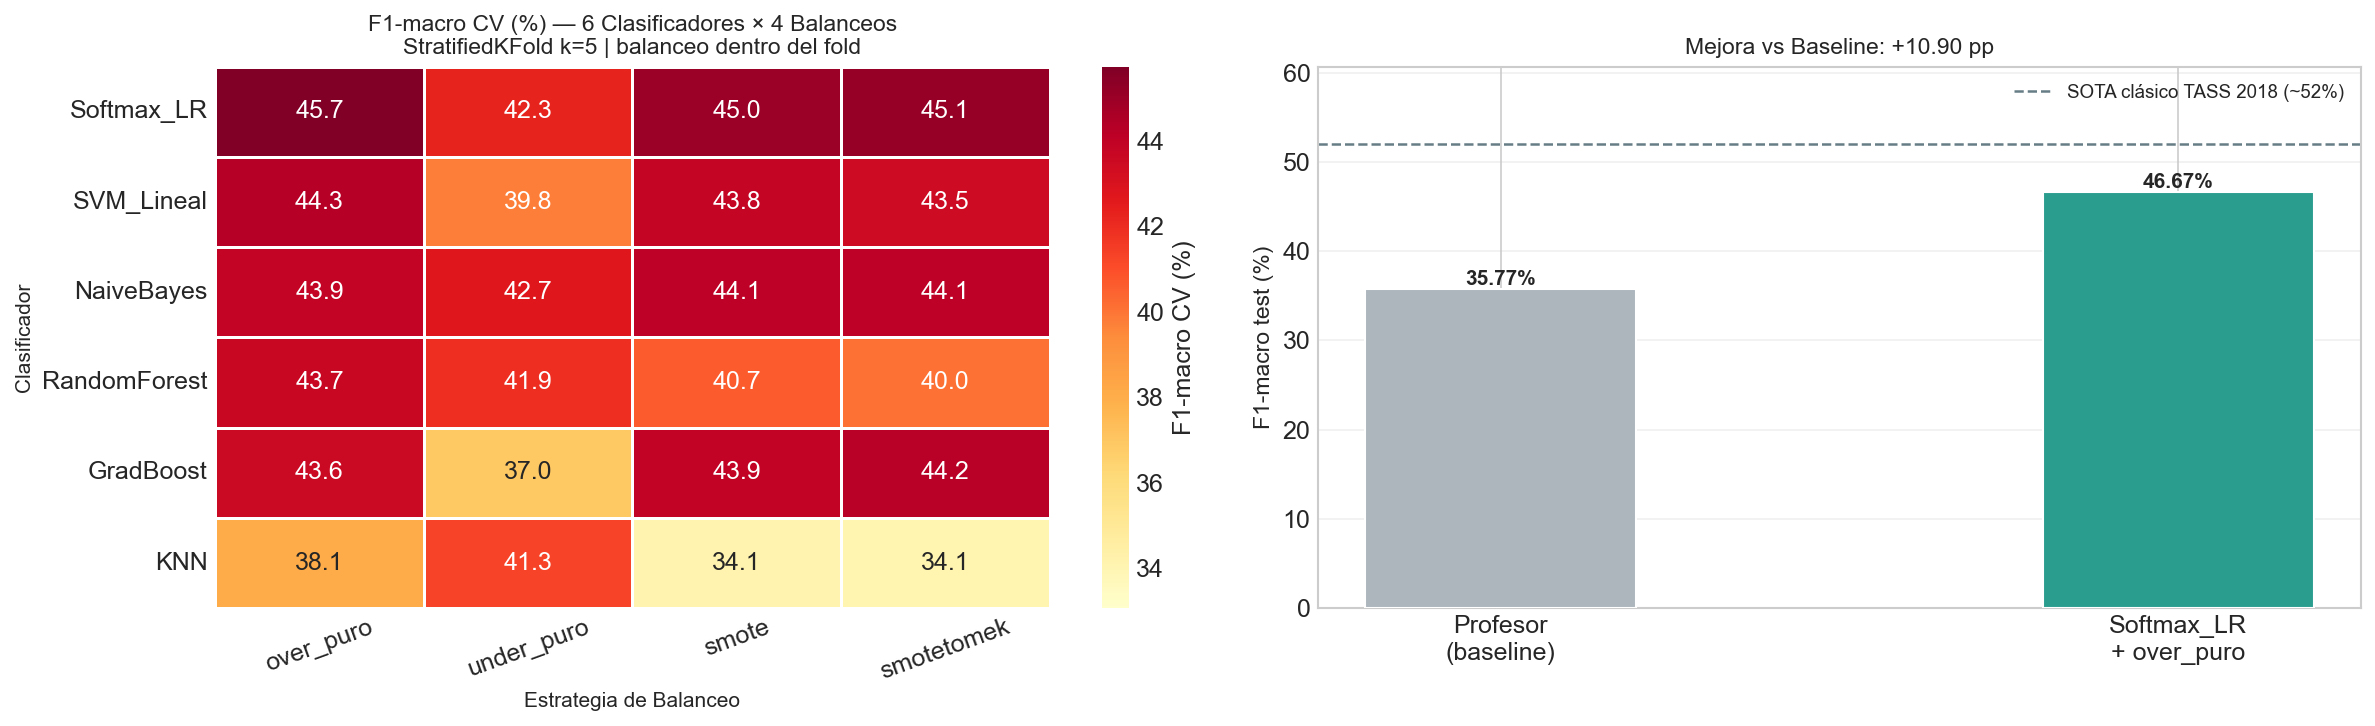

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 75)
print("34. TABLA FINAL COMPARATIVA — TASS 2018 ES")
print("=" * 75)
print(f"\n  📌 Baseline profesor (honesto) : {f1_prof_clean:.2f}%  F1-macro (test set)")
print(f"  📌 SOTA clásico TASS 2018      : ~52%  F1-macro (ELiRF-UPV, SVM+features)")
print(f"  🏆 Mejor modelo V2             : {BEST_FINAL_F1:.2f}%  F1-macro  [{BEST_FINAL_NAME}]")
print(f"  Δ mejora total                 : {BEST_FINAL_F1 - f1_prof_clean:+.2f} pp\n")

# ── Ranking CV top-10 con todas las métricas
print("  Ranking CV — Top 10 (StratifiedKFold k=5, balanceo dentro del fold):")
print(f"  {'#':>2}  {'Clasificador':<18} {'Balanceo':<14} {'F1%':>7}  {'Acc%':>6}  {'Prec%':>6}  {'Rec%':>6}")
print("  " + "─" * 70)
for i, row in df_combo.head(10).iterrows():
    is_best = (f"{row['clf']} + {row['balanceo']}" == BEST_FINAL_NAME)
    flag    = "  ← MEJOR" if is_best else ""
    print(f"  {i+1:>2}. {row['clf']:<18} {row['balanceo']:<14}"
          f" {row['f1_cv']:>6.2f}%  {row['acc_cv']:>5.2f}%  {row['prec_cv']:>5.2f}%  {row['rec_cv']:>5.2f}%{flag}")

# ── Gráficos: heatmap 6×4 + barras comparativas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# — Heatmap F1-macro CV
clf_order = ['Softmax_LR', 'SVM_Lineal', 'NaiveBayes', 'RandomForest', 'GradBoost', 'KNN']
bal_order = ['over_puro', 'under_puro', 'smote', 'smotetomek']
pivot = (df_combo
         .pivot(index='clf', columns='balanceo', values='f1_cv')
         .reindex(index=[c for c in clf_order if c in df_combo['clf'].values],
                  columns=[b for b in bal_order if b in df_combo['balanceo'].values]))
vmin_h = float(pivot.values[~pd.isna(pivot.values)].min()) - 1
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], vmin=vmin_h,
            cbar_kws={'label': 'F1-macro CV (%)'})
axes[0].set_title('F1-macro CV (%) — 6 Clasificadores × 4 Balanceos\n'
                  'StratifiedKFold k=5 | balanceo dentro del fold',
                  fontsize=11)
axes[0].set_xlabel('Estrategia de Balanceo', fontsize=10)
axes[0].set_ylabel('Clasificador', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', rotation=0)

# — Barras comparativas
labels_b = ['Profesor\n(baseline)', BEST_FINAL_NAME.replace(' + ', '\n+ ')]
vals_b   = [f1_prof_clean, BEST_FINAL_F1]
cols_b   = ['#adb5bd', '#2a9d8f']
bars_b   = axes[1].bar(labels_b, vals_b, color=cols_b, width=0.4,
                        edgecolor='white', zorder=3)
axes[1].axhline(y=52, color='#264653', linestyle='--', lw=1.2, alpha=0.7,
                label='SOTA clásico TASS 2018 (~52%)')
for b, v in zip(bars_b, vals_b):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.4,
                 f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, max(vals_b) + 14)
axes[1].set_ylabel('F1-macro test (%)', fontsize=11)
axes[1].set_title(f'Mejora vs Baseline: {BEST_FINAL_F1 - f1_prof_clean:+.2f} pp', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].yaxis.grid(True, alpha=0.3, zorder=0)
axes[1].set_axisbelow(True)

plt.tight_layout()
plt.show()
plt.close('all')
